# `hg19 ENCODE`-provided `rMATS` Comparison (Batch Corrected vs. Not)

## Purpose:

Try to understand to what extent batch effect correction by `ENCODE` actually changed `IncLevels`. 

Workflow: 
* Take all `RBPs` in all cell lines
* Load rMATS results for each splice type (1 file for batch uncorrected and 1 for batch corrected)
* Parse out `IncLevels` from files for each splicing event 
* Remove null values since you can't compare real values to nulls 
* Do a bivariate histogram plot 
* Calculate difference between batch uncorrected and corrected `IncLevels`
* Plot histograms

## Packages and Options

In [1]:
import pandas as pd
pd.set_option('display.max_rows', 1000000)
pd.set_option('display.max_columns', 1000000)
pd.set_option('display.max_colwidth', 10000000)

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import os, glob, sys, seaborn

## Literals

In [2]:
encode_hg19_data_folder = "/project/PlatigLab/TMP_ENCODE_CORRECTED_P_VALUES/"

splice_types = ["A3SS", "A5SS", "SE", "MXE", "RI"]


## Load the `rMATS` Directories for Comparison

In [3]:
rmats_directories = [directory for directory in os.listdir(encode_hg19_data_folder) if "-K562" in directory or "-HepG2" in directory]
print(rmats_directories)

['SUB1-BGKLV13-K562', 'KHSRP-BGHLV12-HepG2', 'WDR43-BGKLV34-K562', 'DDX21-BGHLV14-HepG2', 'DDX59-BGHLV35-HepG2', 'RBM39-BGKLV28-K562', 'HNRNPUL1-BGKLV28-K562', 'NONO-BGKLV19-K562', 'ABCF1-BGHLV30-HepG2', 'STAU1-BGHLV30-HepG2', 'PUF60-BGKLV25-K562', 'UBE2L3-BGKLV25-K562', 'ASCC1-LV08-K562', 'YTHDC2-BGKLV28-K562', 'DDX27-BGHLV17-HepG2', 'SUPV3L1-BGKLV19-K562', 'FMR1-BGKLV36-K562', 'HNRNPK-BGHLV12-HepG2', 'DDX27-BGKLV19-K562', 'DDX52-BGHLV16-HepG2', 'AUH-BGHLV37-HepG2', 'HNRNPA2B1-BGKLV28-K562', 'MATR3-LV11-K562', 'XRN2-BGHLV17-HepG2', 'HDGF-BGHLV31-HepG2', 'PSIP1-BGHLV18-HepG2', 'TIA1-BGHLV12-HepG2', 'SSRP1-BGHLV27-HepG2', 'EIF2S2-BGHLV30-HepG2', 'TIAL1-BGHLV20-HepG2', 'SRP68-BGHLV17-HepG2', 'TRA2A-BGHLV14-HepG2', 'PPIL4-BGHLV20-HepG2', 'TARDBP-LV11-K562', 'GPKOW-BGKLV36-K562', 'RAVER1-BGHLV14-HepG2', 'IGF2BP3-LV11-K562', 'DKC1-BGKLV32-K562', 'SBDS-BGHLV22-HepG2', 'PNPT1-BGHLV22-HepG2', 'FAM120A-BGHLV16-HepG2', 'SUPT6H-BGKLV28-K562', 'PCBP2-LV11-K562', 'UPF1-BGKLV34-K562', 'SRSF3-BGHLV35

## Are Batch Corrected and Non-Corrected Files the Same Length?

In [4]:
# for each directory and splice type within 
for directory in rmats_directories: 
    for splice_type in splice_types: 
        
        # get the 2 splice-type-specific files 
        # 1 for corrected and 1 for non corrected
        files = glob.glob(
            "{}/{}/**/*{}*corrected*".format(encode_hg19_data_folder, directory, splice_type)
        )
        # only should be 2 files 
        assert len(files)==2
        
        # save length of files for both files
        file_lengths = []
        
        for file in files:
            # open and append the length of the file 
            with open(file, 'r') as in_file: 
                file_lengths.append(
                    len(in_file.readlines())
                )
                
        # if the lengths don't match it'll raise an assertion error 
        if file_lengths[0]!=file_lengths[1]: 
            assert(False)

AssertionError: 

**Nope, They have different lengths**

This may be because "noisy" events were removed by `ENCODE`. 

## Inner Join `rMATS` Events Between Batch Corrected and Non-Corrected Files

In [5]:
# dict where key is directory value is another dict 
# sub-dict key is splice type and value is joined table 
joined_data = {}

# for each directory and splice type within 
for directory in rmats_directories: 
    
    joined_data[directory] = {}
    for splice_type in splice_types: 
        
        # get the 2 splice-type-specific files 
        # 1 for corrected and 1 for non corrected
        files = glob.glob(
            "{}/{}/**/*{}*corrected*".format(encode_hg19_data_folder, directory, splice_type)
        )
        
        # only should be 2 files 
        assert len(files)==2
        
        # get corrected file by name key 
        corrected = [file for file in files if "MATS_Norm" in file][0]
        # load into pandas and have ID column as index 
        corrected = pd.read_csv(
            corrected, 
            sep="\t", 
            index_col = 0
        )
        
        # same as above for uncorrected 
        uncorrected = [file for file in files if "MATS_output" in file][0]
        uncorrected = pd.read_csv(
            uncorrected,
            sep="\t",
            index_col = 0
        )
                
        # inner join the two dataframes and save
        # make sure to validate that the key mappings are 1-to-1
        tmp_joined_df = corrected.join(
            uncorrected,
            how="inner",
            lsuffix="_CORRECTED", 
            rsuffix = "_NOT", 
            validate = "1:1"
        )
        
        # make sure that the Gene IDs are the same for events as well
        assert tmp_joined_df["GeneID_CORRECTED"].equals(
            tmp_joined_df["GeneID_NOT"]
        )
        
        # get columns corresponding to inclevels
        inclevel_columns = [ column for column in tmp_joined_df.columns.to_list() if "IncLevel1" in column or "IncLevel2" in column]
        
        joined_data[directory][splice_type] = tmp_joined_df[inclevel_columns] 

## Can You Relate Event IDs Between Batch Corrected and Uncorrected Files?

Look at `ENSEMBL Gene ID`s to double check they're all the same. 

This isn't perfect but if they have the same `rMATS` ID and the same `Gene ID`, 

they're likely referring to the same event (a good thing). 


**Yes, IDs can be related between the batch corrected and not corrected files**

**This is proven in the code block before with the assertion statement near the end**

## Store PSI Values Before and After Correction

In [6]:
# corrected and uncorrected list values  
corrected = []
uncorrected = []

for directory in rmats_directories: 
    
    for splice_type in splice_types:
        
        tmp_joined_df = joined_data[directory][splice_type]
        
        tmp_joined_df = tmp_joined_df.apply(lambda x: (",".join(x)).split(","), axis=0)
        
        uncorrected.extend(tmp_joined_df["IncLevel1_NOT"].to_list())
        uncorrected.extend(tmp_joined_df["IncLevel2_NOT"].to_list())
        
        corrected.extend(tmp_joined_df["IncLevel1_CORRECTED"].to_list())
        corrected.extend(tmp_joined_df["IncLevel2_CORRECTED"].to_list())

assert len(corrected) == len(uncorrected)

## Find Number of "NA" Values

`IncLevel` can be null if there are no counts (divide by zero error)

In [7]:
uncorrected_no_null = [value for value in uncorrected if value!="NA"]
corrected_no_null = [value for value in corrected if value!="NA"]

"Length of non-null uncorrected values: {}".format(
    len(uncorrected_no_null)
)

"Length of non-null corrected values: {}".format(
    len(corrected_no_null)
)

del uncorrected_no_null
del corrected_no_null

'Length of non-null uncorrected values: 113366004'

'Length of non-null corrected values: 112942517'

#### That's strange! Why do the numbers differ? 

That would mean that values that were originally null are now not-null or vice versa. 

That makes no sense! 

However, we will load these two lists into a `Pandas DataFrame` and confirm if this is true. 


In [8]:
plotting_df = pd.DataFrame(
    {
        "Corrected": corrected, 
        "Uncorrected": uncorrected
    }
)

xor_na = plotting_df[(plotting_df["Corrected"]=="NA") ^ (plotting_df["Uncorrected"] =="NA")]

xor_na.head()

"Number of events where one of corrected or uncorrected values are 'NA' but the other one is not: {}".format(
    xor_na.index.size

)

"Same as above but as a percentage of the total number of events: {}".format(
    xor_na.index.size/plotting_df.index.size
)

,Corrected,Uncorrected
35,0.485,NA
50,NA,0.0
77,NA,0.0
146,NA,0.0
276,NA,0.352


"Number of events where one of corrected or uncorrected values are 'NA' but the other one is not: 2468655"

'Same as above but as a percentage of the total number of events: 0.021533818140202044'

## Remove "NA" Values

In [9]:
"Size of dataframe BEFORE removing rows that have 'NA' for either corrected or uncorrected: {}".format(
    plotting_df.index.size
)

plotting_df = plotting_df[
    (plotting_df["Corrected"]!="NA") & (plotting_df["Uncorrected"]!="NA")
]

plotting_df = plotting_df.astype('float64')

"Size of dataframe AFTER removing rows that have 'NA' for either corrected or uncorrected: {}".format(
    plotting_df.index.size
)


"Size of dataframe BEFORE removing rows that have 'NA' for either corrected or uncorrected: 114640840"

"Size of dataframe AFTER removing rows that have 'NA' for either corrected or uncorrected: 111919933"

## Correlation, KDE and Hist Plots Comparing Corrected and Uncorrected Counts 

In [10]:
plotting_df["Corrected"].corr(plotting_df["Uncorrected"])

0.9315802363500337

<Axes: xlabel='Uncorrected', ylabel='Corrected'>

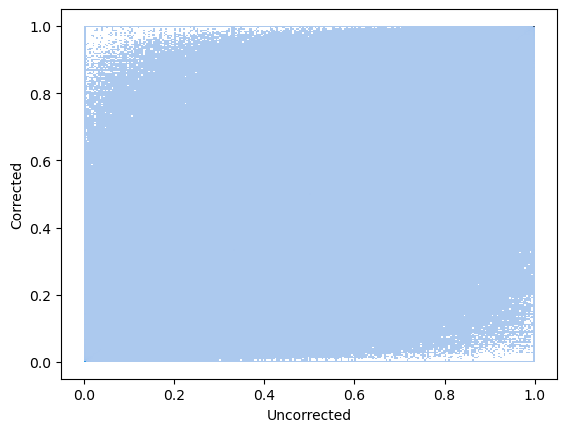

In [11]:
seaborn.histplot(plotting_df, x="Uncorrected", y="Corrected")

**It may also just be useful to plot the difference between Corrected and Uncorrected counts as a plot**

## KDE Plot for Difference between Corrected and Uncorrected `IncLevel` Values

In [12]:
plotting_df["Difference"] = plotting_df["Corrected"] - plotting_df["Uncorrected"]

<Axes: xlabel='Difference', ylabel='Count'>

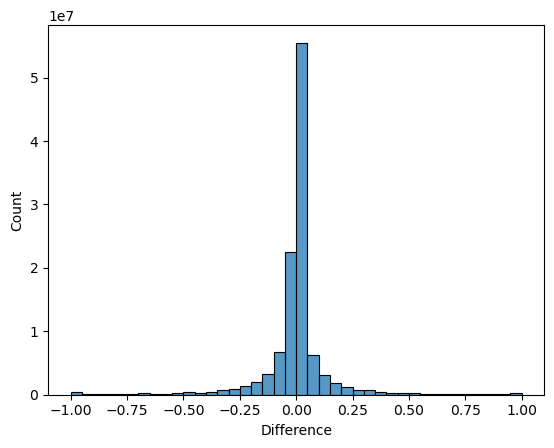

In [13]:
seaborn.histplot(plotting_df, x="Difference", bins=40)

<Axes: xlabel='Difference', ylabel='Count'>

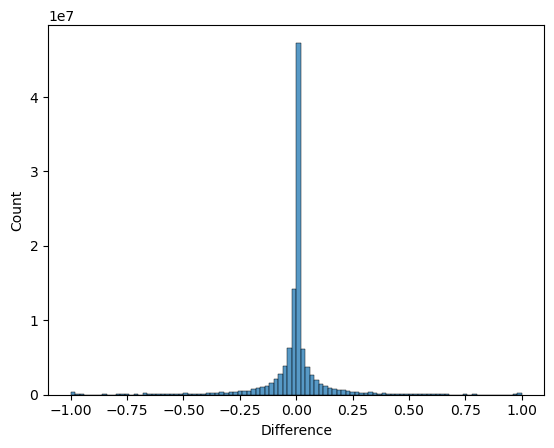

In [14]:
seaborn.histplot(plotting_df, x="Difference", bins=100)

<Axes: xlabel='Difference', ylabel='Count'>

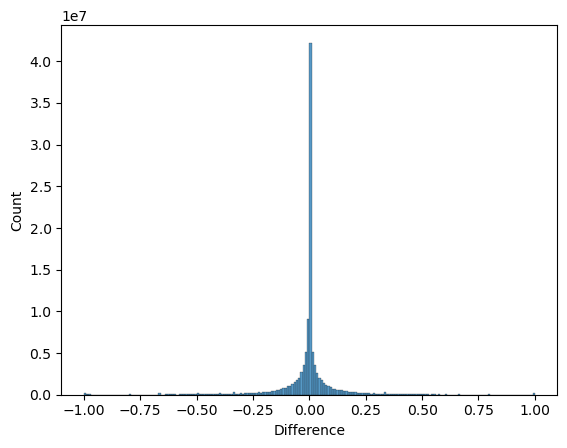

In [15]:
seaborn.histplot(plotting_df, x="Difference", bins=200)